# Thư viện

In [1]:
import osmnx as ox

import pandas as pd
import numpy as np

from pathlib import Path

import requests
import json

from rapidfuzz import fuzz
from unidecode import unidecode

# Load các file csv

In [2]:
PATH = Path("../data/raw")

files = {
    "nodes": PATH / "nodes.csv",
    "streets": PATH / "streets.csv",
    "segments": PATH / "segments.csv",
    "status": PATH / "segment_status.csv",
    "train": PATH / "train.csv"
}

In [3]:
nodes_df = pd.read_csv(files["nodes"])
streets_df = pd.read_csv(files["streets"])
segments_df = pd.read_csv(files["segments"])
status_df = pd.read_csv(files["status"])
train_df = pd.read_csv(files["train"])

In [4]:
train_nodes = list(set(train_df["s_node_id"]) | set(train_df["e_node_id"]))

In [5]:
train_streets = set(train_df["street_id"].to_list())

# Tải graph

# Load graph

In [6]:
with open("../data/raw/osm_train_2019_09_18.json", "r", encoding="utf-8") as f:
    osm_data = json.load(f)

In [7]:
osm_data.keys()

dict_keys(['version', 'generator', 'osm3s', 'elements'])

In [8]:
osm_data["version"]

0.6

## OSM Element

In [9]:
osm_elements = pd.DataFrame(osm_data["elements"])

In [10]:
osm_elements.head()

,type,id,lat,lon,tags,nodes,members
0,node,366367322,10.799149,106.657144,NaN,NaN,NaN
1,node,366367392,10.775755,106.614047,NaN,NaN,NaN
2,node,366367451,10.793767,106.695338,NaN,NaN,NaN
3,node,366367839,10.807689,106.664528,NaN,NaN,NaN
4,node,366367847,10.814589,106.671636,NaN,NaN,NaN


In [11]:
osm_elements["type"].unique()

array(['node', 'way', 'relation'], dtype=object)

## OSM Node

In [12]:
osm_nodes = osm_elements[osm_elements["type"] == "node"]

In [13]:
osm_nodes.head()

,type,id,lat,lon,tags,nodes,members
0,node,366367322,10.799149,106.657144,NaN,NaN,NaN
1,node,366367392,10.775755,106.614047,NaN,NaN,NaN
2,node,366367451,10.793767,106.695338,NaN,NaN,NaN
3,node,366367839,10.807689,106.664528,NaN,NaN,NaN
4,node,366367847,10.814589,106.671636,NaN,NaN,NaN


## OSM Way

In [14]:
osm_ways = osm_elements[osm_elements["type"] == "way"]

In [15]:
print(osm_ways.shape)
osm_ways.head()

(8330, 7)


,type,id,lat,lon,tags,nodes,members
2914,way,32575768,NaN,NaN,"{'highway': 'residential', 'lanes': '2', 'name...","[366369613, 5795144851, 366418963, 366373068, ...",NaN
2915,way,32576350,NaN,NaN,"{'highway': 'residential', 'lanes': '2', 'name...","[2269043918, 366372346, 6754138053, 6754138038...",NaN
2916,way,32576691,NaN,NaN,"{'name': 'Phan Văn Hớn', 'name:en': 'Phan Van ...","[366452320, 3351962143, 3351962141, 366375776,...",NaN
2917,way,32576911,NaN,NaN,"{'name': 'Đường Tân Thành', 'highway': 'reside...","[5778381634, 6637725838, 6712462069, 671246206...",NaN
2918,way,32577060,NaN,NaN,{'highway': 'residential'},"[366371080, 366389438, 5735589498, 5735589492,...",NaN


# Khai phá dữ liệu

## OSM Node

In [16]:
osm_nodes.isnull().sum() * 100 / len(osm_nodes)

type         0.000000
id           0.000000
lat          0.000000
lon          0.000000
tags        91.409071
nodes      100.000000
members    100.000000
dtype: float64

In [17]:
# Xem các tag không null
osm_nodes[~osm_nodes["tags"].isnull()]

,type,id,lat,lon,tags,nodes,members
13,node,366368118,10.829360,106.671896,"{'crossing': 'uncontrolled', 'highway': 'cross...",NaN,NaN
25,node,366368730,10.868648,106.734830,{'highway': 'traffic_signals'},NaN,NaN
38,node,366369424,10.797353,106.672682,{'highway': 'traffic_signals'},NaN,NaN
70,node,366371269,10.764439,106.645120,"{'crossing': 'uncontrolled', 'highway': 'cross...",NaN,NaN
98,node,366372531,10.809108,106.674142,{'highway': 'traffic_signals'},NaN,NaN
...,...,...,...,...,...,...,...
63535,node,5963104799,10.792283,106.751946,"{'crossing': 'traffic_signals', 'highway': 'tr...",NaN,NaN
63707,node,6751317803,10.774520,106.661934,"{'crossing': 'uncontrolled', 'highway': 'cross...",NaN,NaN
63708,node,6753880417,10.759552,106.658195,{'barrier': 'gate'},NaN,NaN
63709,node,6757272704,10.792281,106.752006,"{'crossing': 'traffic_signals', 'highway': 'tr...",NaN,NaN


In [18]:
osm_nodes.shape

(55384, 7)

In [19]:
osm_nodes.head()

,type,id,lat,lon,tags,nodes,members
0,node,366367322,10.799149,106.657144,NaN,NaN,NaN
1,node,366367392,10.775755,106.614047,NaN,NaN,NaN
2,node,366367451,10.793767,106.695338,NaN,NaN,NaN
3,node,366367839,10.807689,106.664528,NaN,NaN,NaN
4,node,366367847,10.814589,106.671636,NaN,NaN,NaN


In [20]:
filtered_osm_nodes = osm_nodes[osm_nodes["id"].isin(train_nodes)]
filtered_osm_nodes.shape

(10522, 7)

In [21]:
osm_node_tags_df = pd.json_normalize(
    filtered_osm_nodes["tags"]
        .where(
            filtered_osm_nodes["tags"].notna(), 
            other=[{}]
        )
)

In [22]:
osm_node_tags_df.insert(0, "node_id", filtered_osm_nodes["id"].to_numpy())

In [23]:
print(osm_node_tags_df.shape)
osm_node_tags_df.head()

(10522, 33)


,node_id,crossing,highway,railway,traffic_signals,name,note,operator,addr:street,addr:housenumber,...,network,ref,traffic_calming,wheelchair,shop,amenity,cuisine,diet:vegetarian,diet:vegan,flashing_lights
0,366367392,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,366367451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,366367839,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,366367847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,366368010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
node_null_df = osm_node_tags_df.isnull().sum().to_frame(name="count")
node_null_df["perc"]= node_null_df["count"] * 100 / len(osm_node_tags_df)
node_null_df.sort_values("perc")

,count,perc
node_id,0,0.000000
highway,9791,93.052652
name,10105,96.036875
crossing,10379,98.640943
note,10419,99.021099
operator,10478,99.581829
traffic_signals,10486,99.657860
addr:street,10489,99.686371
addr:housenumber,10490,99.695875
crossing_ref,10502,99.809922


In [25]:
osm_node_tags_df["highway"].unique()

array([nan, 'crossing', 'traffic_signals', 'bus_stop'], dtype=object)

In [26]:
osm_node_tags_df["crossing"].unique()

array([nan, 'uncontrolled', 'traffic_signals', 'zebra'], dtype=object)

## OSM way

In [27]:
filtered_osm_ways = osm_ways[osm_ways["id"].isin(train_streets)]

In [28]:
filtered_osm_ways.isnull().sum() * 100 / len(filtered_osm_ways)

type         0.0
id           0.0
lat        100.0
lon        100.0
tags         0.0
nodes        0.0
members    100.0
dtype: float64

In [29]:
# Bỏ hoàn toàn cột null
filtered_osm_ways.columns

Index(['type', 'id', 'lat', 'lon', 'tags', 'nodes', 'members'], dtype='object')

In [30]:
# Xây dựng các cạnh
segments = []

for _, row in filtered_osm_ways.iterrows():
    nodes = row["nodes"]

    if isinstance(nodes, list) and len(nodes) >= 2:
        for u, v in zip(nodes[:-1], nodes[1:]):
            segments.append({
                "street_id": row["id"],
                "s_node_id": u,
                "e_node_id": v
            })

osm_segments_df = pd.DataFrame(segments)

In [31]:
print(osm_segments_df.shape)
osm_segments_df.head()

(21798, 3)


,street_id,s_node_id,e_node_id
0,32577244,366445888,2434647895
1,32577244,2434647895,6713197753
2,32577244,6713197753,4929127560
3,32577244,4929127560,366388735
4,32577244,366388735,366474637


In [32]:
osm_ways_tags_df = pd.json_normalize(
    filtered_osm_ways["tags"]
        .where(
            filtered_osm_ways["tags"]
                .notna(), 
            other=[{}]
        )
)

In [33]:
osm_ways_tags_df.insert(0, "way_id", filtered_osm_ways["id"].to_numpy())

In [34]:
print(osm_ways_tags_df.shape)
osm_ways_tags_df.head()

(1786, 117)


,way_id,name,hgv,highway,lanes,maxweight:conditional,surface,maxspeed,maxweight,name:en,...,name:th,date,lay,turn:lanes:forward,motorcycle:lanes:foward,motor_vehicle:lanes:forward,hgv_articulated:conditional,lanes:motorcycle:forward,maxpeed:hgv,motor_vehicle:conditional
0,32577244,Tôn Thất Hiệp,no,tertiary,2,2.5 @ (06:00-22:00),asphalt,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,32577484,Gò Dưa,NaN,tertiary,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,32577508,Kha Vạn Cân,NaN,tertiary,2,NaN,asphalt,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,32578529,Tân Chánh Hiệp 39,NaN,tertiary,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,32578530,đường PHẠM THỊ GIÂY,NaN,unclassified,NaN,NaN,NaN,40,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
way_tags_null_df = osm_ways_tags_df.isnull().sum().to_frame(name="count")
way_tags_null_df["perc"]= way_tags_null_df["count"] * 100 / len(osm_ways_tags_df)
way_tags_null_df.sort_values("perc").head(10)

,count,perc
way_id,0,0.000000
highway,0,0.000000
name,255,14.277716
oneway,496,27.771557
surface,810,45.352744
lanes,925,51.791713
name:en,1345,75.307951
maxspeed,1444,80.851064
ref,1601,89.641657
layer,1604,89.809630


In [36]:
"""
from collections import Counter

prefix_count = Counter()

for s in way_tags_cols:
    prefix = s.split(":")[0]
    prefix_count[prefix] += 1

# lọc bỏ prefix >= 2
filtered = []

for s in way_tags_cols:
    prefix = s.split(":")[0]

    if prefix_count[prefix] < 2:
        filtered.append(s)

print(filtered)
"""

'\nfrom collections import Counter\n\nprefix_count = Counter()\n\nfor s in way_tags_cols:\n    prefix = s.split(":")[0]\n    prefix_count[prefix] += 1\n\n# lọc bỏ prefix >= 2\nfiltered = []\n\nfor s in way_tags_cols:\n    prefix = s.split(":")[0]\n\n    if prefix_count[prefix] < 2:\n        filtered.append(s)\n\nprint(filtered)\n'

In [37]:
way_tags_cols = osm_ways_tags_df.columns

In [38]:
def prefix_count(prefix: list[str]):
    for s in prefix:
        count = sum(1 for col in way_tags_cols if col.startswith(s))
        print(f"Số lượng cột bắt đầu bằng '{s}': {count}")

In [39]:
prefix_list = [
    "name",
    "old_name",
    "maxspeed",
    "maxweight"
]

prefix_count(prefix_list)

Số lượng cột bắt đầu bằng 'name': 8
Số lượng cột bắt đầu bằng 'old_name': 5
Số lượng cột bắt đầu bằng 'maxspeed': 9
Số lượng cột bắt đầu bằng 'maxweight': 6


In [40]:
way_tags_cols = [
    col for col in way_tags_cols if not (
        col.startswith("name") or
        col.startswith("old_name")
    )
]
sorted(way_tags_cols)

['access',
 'addr:city',
 'addr:district',
 'addr:subdistrict',
 'alt_name',
 'area',
 'bicycle',
 'bicycle:oneway',
 'bridge',
 'bridge:name',
 'bus',
 'bus:conditional',
 'bus:lanes',
 'car',
 'construction',
 'date',
 'description',
 'destination:district',
 'destination:int_ref',
 'destination:ref',
 'destination:street',
 'destination:street:backward',
 'destination:street:forward',
 'destination:street:to',
 'fixme',
 'foot',
 'hgv',
 'hgv:conditional',
 'hgv:lanes',
 'hgv_articulated',
 'hgv_articulated:conditional',
 'highway',
 'horse',
 'int_ref',
 'junction',
 'lanes',
 'lanes:backward',
 'lanes:bus',
 'lanes:forward',
 'lanes:motor_vehicle',
 'lanes:motorcycle',
 'lanes:motorcycle:forward',
 'lay',
 'layer',
 'level',
 'lit',
 'maxheight',
 'maxpeed:hgv',
 'maxspeed',
 'maxspeed:articulated_hgv',
 'maxspeed:bus',
 'maxspeed:hgv',
 'maxspeed:hgv_articulated',
 'maxspeed:lanes',
 'maxspeed:motor_car',
 'maxspeed:motor_vehicle',
 'maxspeed:motorcar',
 'maxweight',
 'maxweight:

### Topology

In [41]:
osm_ways_tags_df["access"].unique()

array([nan, 'yes', 'permissive', 'no', 'private'], dtype=object)

In [42]:
osm_ways_tags_df["highway"].unique()

array(['tertiary', 'unclassified', 'residential', 'primary', 'secondary',
       'trunk', 'tertiary_link', 'service', 'primary_link', 'trunk_link',
       'secondary_link', 'motorway_link', 'motorway'], dtype=object)

In [43]:
osm_ways_tags_df["oneway"].unique()

array([nan, 'yes', 'no'], dtype=object)

In [44]:
osm_ways_tags_df["junction"].unique()

array([nan, 'roundabout', 'circular'], dtype=object)

In [45]:
osm_ways_tags_df["bridge"].unique()

array([nan, 'yes'], dtype=object)

In [46]:
osm_ways_tags_df["tunnel"].unique()

array([nan, 'yes', 'building_passage'], dtype=object)

In [47]:
osm_ways_tags_df["layer"].unique()

array([nan, '1', '3', '2', '5', '-1'], dtype=object)

In [48]:
topology_feats = [
    "access",
    "highway",
    "oneway",
    "junction",
    "bridge",
    "tunnel",
    "layer"
]

### Capacity

In [49]:
osm_ways_tags_df["minspeed"].unique()

array([nan, '60'], dtype=object)

In [50]:
osm_ways_tags_df["maxspeed"].unique()

array([nan, '40', '50', '80', '60', '30', '20', '45', '70', '10', '120',
       '100'], dtype=object)

In [51]:
osm_ways_tags_df["maxweight"].unique()

array([nan, '3.5', '2.5', '8', '1.5', '25', '3', '13', '10'], dtype=object)

In [52]:
osm_ways_tags_df["lanes"].unique()

array(['2', nan, '3', '4', '5', '1', '6'], dtype=object)

In [53]:
osm_ways_tags_df["hgv"].unique()

array(['no', nan, 'delivery'], dtype=object)

In [54]:
osm_ways_tags_df["surface"].unique()

array(['asphalt', nan, 'paved', 'concrete', 'unpaved', 'dirt', 'sett'],
      dtype=object)

In [55]:
capacity_feats = [
    "minspeed",
    "maxweight",
    "lanes",
    "maxspeed",
    "surface"
]

### Traffic control

In [56]:
traffic_control_feats = [
    "hgv",
    "bicycle",
    "moped",
    "mofa",
    "motorcar",
    "motorcycle",
    "stop",
    "motor_vehicle",
    "foot"
]

### All feats

In [57]:
features = topology_feats + capacity_feats + traffic_control_feats

In [58]:
known_feats = [
    "way_id", 
    "note",
    "ref", 
    "old_ref", 
    "note",
    "name", 
    "old_name", 
    "addr", 
    "description",
    "destination",
    "official_name",
    "alt_name",
    "wikidata"
] + topology_feats + capacity_feats + traffic_control_feats

In [59]:
filtered_cols = [
    col for col in way_tags_cols
    if not any(col.startswith(f"{feat}:") or col == feat for feat in known_feats)
]

sorted(filtered_cols)

['area',
 'bus',
 'bus:conditional',
 'bus:lanes',
 'car',
 'construction',
 'date',
 'fixme',
 'hgv_articulated',
 'hgv_articulated:conditional',
 'horse',
 'int_ref',
 'lay',
 'level',
 'lit',
 'maxheight',
 'maxpeed:hgv',
 'motorroad',
 'overtaking',
 'psv:conditional',
 'sidewalk',
 'source',
 'source:maxspeed',
 'surfaces',
 'taxi:conditional',
 'taxi:lanes',
 'traffic_signals:direction',
 'turn:lanes',
 'turn:lanes:forward',
 'width']

## OSM relation

In [60]:
osm_relations = osm_elements[osm_elements["type"] == "relation"]

In [61]:
print(osm_relations.shape)
osm_relations.head()

(146, 7)


,type,id,lat,lon,tags,nodes,members
3071,relation,9674571,NaN,NaN,"{'type': 'restriction', 'restriction': 'no_lef...",NaN,"[{'type': 'way', 'ref': 213726584, 'role': 'fr..."
3072,relation,9926053,NaN,NaN,"{'except': 'bicycle;hgv;moped;psv', 'restricti...",NaN,"[{'type': 'way', 'ref': 242003623, 'role': 'fr..."
3073,relation,9931867,NaN,NaN,"{'except': 'bicycle;hgv;moped;psv', 'restricti...",NaN,"[{'type': 'way', 'ref': 32577244, 'role': 'fro..."
3074,relation,9942310,NaN,NaN,{'restriction:conditional': 'no_u_turn @ (06:0...,NaN,"[{'type': 'way', 'ref': 516774803, 'role': 'vi..."
3075,relation,9951517,NaN,NaN,"{'except': 'bicycle;hgv;moped;psv', 'restricti...",NaN,"[{'type': 'way', 'ref': 32584146, 'role': 'fro..."


In [62]:
osm_relations.isnull().sum() * 100 / len(osm_relations)

type         0.0
id           0.0
lat        100.0
lon        100.0
tags         0.0
nodes      100.0
members      0.0
dtype: float64

In [63]:
osm_relations.columns

Index(['type', 'id', 'lat', 'lon', 'tags', 'nodes', 'members'], dtype='object')

In [64]:
osm_relations = osm_relations.drop(columns=["lat", "lon", "nodes"])

In [65]:
osm_relations["members"].head()

3071    [{'type': 'way', 'ref': 213726584, 'role': 'fr...
3072    [{'type': 'way', 'ref': 242003623, 'role': 'fr...
3073    [{'type': 'way', 'ref': 32577244, 'role': 'fro...
3074    [{'type': 'way', 'ref': 516774803, 'role': 'vi...
3075    [{'type': 'way', 'ref': 32584146, 'role': 'fro...
Name: members, dtype: object

In [66]:
osm_relation_members_df = (
    osm_relations["members"]
    .explode()              # tách từng phần tử trong list thành từng dòng
    .apply(pd.Series)       # convert dict -> columns
)

osm_relation_members_df.head()

,type,ref,role
3071,way,213726584,from
3071,way,408251572,to
3071,node,5769343546,via
3072,way,242003623,from
3072,way,32582173,to


In [67]:
osm_relation_members_df[osm_relation_members_df["role"] != ""].head()

,type,ref,role
3071,way,213726584,from
3071,way,408251572,to
3071,node,5769343546,via
3072,way,242003623,from
3072,way,32582173,to


In [68]:
osm_relation_members_df["role"].unique()

array(['from', 'to', 'via'], dtype=object)

In [69]:
osm_relations_tags_df = pd.json_normalize(
    osm_relations["tags"]
        .where(
            osm_relations["tags"]
                .notna(), 
            other=[{}]
        )
)

osm_relations_tags_df.head()

,type,restriction,except,restriction:conditional,hour_off,hour_on,restriction:motorcar,implicit,conditional:restriction,motorcar,restriction:motor_vehicle:conditional
0,restriction,no_left_turn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,restriction,no_left_turn,bicycle;hgv;moped;psv,"no_left_turn @ (06:00-09:00,16:00-20:00)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,restriction,no_left_turn,bicycle;hgv;moped;psv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,restriction,no_u_turn,psv;hgv;motorcycle;bicycle,"no_u_turn @ (06:00-09:00,16:00-22:00)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,restriction,no_left_turn,bicycle;hgv;moped;psv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
osm_relations_tags_df.shape

(146, 11)

In [71]:
osm_relations_tags_df[osm_relations_tags_df["type"] == "route"]

,type,restriction,except,restriction:conditional,hour_off,hour_on,restriction:motorcar,implicit,conditional:restriction,motorcar,restriction:motor_vehicle:conditional


## Node

### Nodes _id

In [72]:
nodes = nodes_df["_id"].values

In [73]:
osm_node_id = set(osm_nodes["id"])

In [74]:
osm_nodes[osm_nodes["id"].isin(nodes)]

,type,id,lat,lon,tags,nodes,members
0,node,366367322,10.799149,106.657144,NaN,NaN,NaN
1,node,366367392,10.775755,106.614047,NaN,NaN,NaN
2,node,366367451,10.793767,106.695338,NaN,NaN,NaN
3,node,366367839,10.807689,106.664528,NaN,NaN,NaN
4,node,366367847,10.814589,106.671636,NaN,NaN,NaN
...,...,...,...,...,...,...,...
63831,node,6175932027,10.768841,106.646204,NaN,NaN,NaN
63832,node,6175932028,10.768937,106.646072,NaN,NaN,NaN
63833,node,6175932033,10.769777,106.646644,NaN,NaN,NaN
63834,node,6175932047,10.766245,106.644705,NaN,NaN,NaN


### Nodes location

In [75]:
node_locs = set(nodes_df.apply(tuple, axis=1))

In [76]:
osm_node_locs = set(osm_nodes[["id", "lon", "lat"]].apply(tuple, axis=1))

In [77]:
inter_osm_nodes_locs = node_locs & osm_node_locs
print(len(nodes_df))
print(len(osm_node_locs))
print(len(inter_osm_nodes_locs))

577967
55384
38885


In [78]:
nodes_df.head()

,_id,long,lat
0,366367223,106.629056,10.804243
1,366367233,106.709701,10.771110
2,366367242,106.737189,10.709337
3,366367274,106.760081,10.854489
4,366367285,106.721163,10.804994


### Đánh giá khoảng cách tọa độ

In [79]:
temp_osm_nodes_df = osm_nodes[["id", "lon", "lat"]].copy()
temp_osm_nodes_df = temp_osm_nodes_df.rename(columns={
    "id": "_id",
    "lon": "long"
})
temp_nodes_df = nodes_df.copy()
combine_nodes_df = pd.concat([temp_osm_nodes_df, temp_nodes_df])
combine_nodes_df = combine_nodes_df.reset_index(drop=True).drop_duplicates()
print(combine_nodes_df.shape)
combine_nodes_df.head()

(594466, 3)


,_id,long,lat
0,366367322,106.657144,10.799149
1,366367392,106.614047,10.775755
2,366367451,106.695338,10.793767
3,366367839,106.664528,10.807689
4,366367847,106.671636,10.814589


In [80]:
from haversine import haversine, Unit

node_conflict_df = pd.DataFrame(
    columns=["_id", "longs", "lats", "avg_long", "avg_lat", "avg_dist_m"]
)

count = 0

for _id, group in combine_nodes_df.groupby("_id"):

    if count == 4:
        break

    # chỉ xử lý group có 2 node
    if len(group) == 2:

        print(f"_id = {_id}")
        print(group)
        print("-" * 50)

        # lấy longitude / latitude
        longs = group["long"].values
        lats = group["lat"].values

        # tọa độ trung bình
        avg_long = longs.mean()
        avg_lat = lats.mean()

        # khoảng cách thực tế (mét)
        p1 = (lats[0], longs[0])
        p2 = (lats[1], longs[1])

        dist_meter = haversine(p1, p2, unit=Unit.METERS)

        # thêm vào dataframe
        node_conflict_df.loc[len(node_conflict_df)] = {
            "_id": _id,
            "longs": longs.tolist(),
            "lats": lats.tolist(),
            "avg_long": avg_long,
            "avg_lat": avg_lat,
            "avg_dist_m": dist_meter
        }

        print(f"avg = ({avg_long}, {avg_lat})")
        print(f"distance = {dist_meter:.3f} m")
        print("=" * 50)

        count += 1

_id = 366367322
             _id        long        lat
0      366367322  106.657144  10.799149
55390  366367322  106.657136  10.799155
--------------------------------------------------
avg = (106.6571399, 10.799151649999999)
distance = 1.093 m
_id = 366367392
             _id        long        lat
1      366367392  106.614047  10.775755
55401  366367392  106.614032  10.775732
--------------------------------------------------
avg = (106.6140394, 10.77574375)
distance = 3.070 m
_id = 366367451
             _id        long        lat
2      366367451  106.695338  10.793767
55409  366367451  106.695366  10.793792
--------------------------------------------------
avg = (106.6953522, 10.7937794)
distance = 4.105 m
_id = 366367461
             _id        long        lat
38644  366367461  106.650140  10.774833
55411  366367461  106.650128  10.774879
--------------------------------------------------
avg = (106.65013375000001, 10.77485575)
distance = 5.261 m


In [81]:
node_conflict_df["avg_dist_m"].mean()

np.float64(3.382325588716709)

In [82]:
node_conflict_df["avg_dist_m"].min(), node_conflict_df["avg_dist_m"].max()

(np.float64(1.0926759615470245), np.float64(5.261437766184184))

In [83]:
node_conflict_df[node_conflict_df["avg_dist_m"] == node_conflict_df["avg_dist_m"].max()]

,_id,longs,lats,avg_long,avg_lat,avg_dist_m
3,366367461,"[106.6501396, 106.6501279]","[10.7748328, 10.7748787]",106.650134,10.774856,5.261438


C:\Users\Asriel\AppData\Local\Temp\ipykernel_3712\3940147825.py:11: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



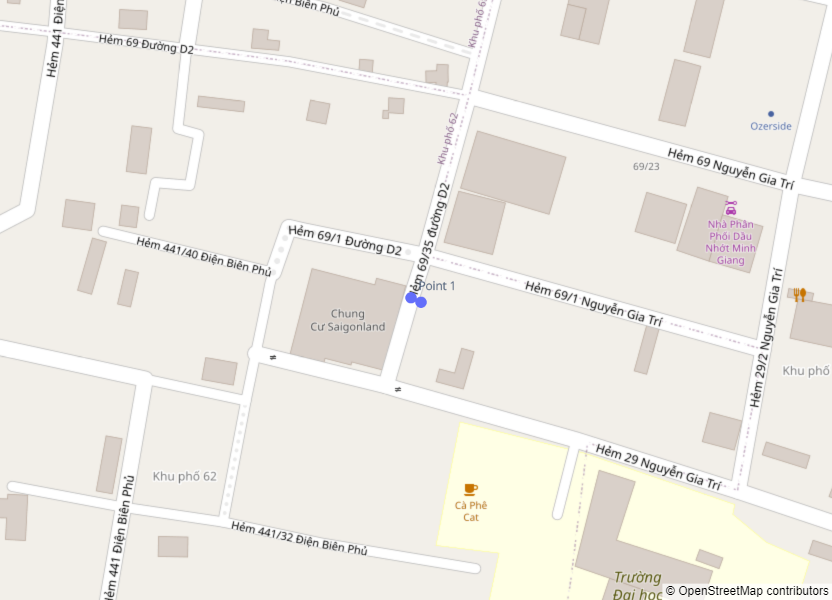

In [84]:
import plotly.graph_objects as go

# Tọa độ
lats = [10.8031111, 10.8030992]
longs = [106.7142612, 106.714288]

# Tạo figure
fig = go.Figure()

# Vẽ điểm + đường nối
fig.add_trace(go.Scattermapbox(
    lat=lats,
    lon=longs,
    mode="markers+lines+text",
    marker=dict(size=12),
    text=["Point 1", "Point 2"],
    textposition="top right",
    line=dict(width=3),
))

# Layout map
fig.update_layout(
    mapbox_style="open-street-map",
    mapbox_zoom=18,
    mapbox_center=dict(
        lat=sum(lats) / len(lats),
        lon=sum(longs) / len(longs)
    ),
    margin=dict(l=0, r=0, t=0, b=0),
    height=600
)

fig.show()

### Chứng minh các node streets thuộc đường của osm

## Street

In [85]:
osm_segments_df.head()

,street_id,s_node_id,e_node_id
0,32577244,366445888,2434647895
1,32577244,2434647895,6713197753
2,32577244,6713197753,4929127560
3,32577244,4929127560,366388735
4,32577244,366388735,366474637


In [86]:
streets_street_id = set(streets_df["_id"])
osm_streets_street_id = set(osm_segments_df["street_id"])

In [87]:
inter_osm_streets_street_id = streets_street_id & osm_streets_street_id
print(len(streets_street_id))
print(len(osm_streets_street_id))
print(len(inter_osm_streets_street_id))

5553
1786
1786


In [88]:
inter_street_id = list(inter_osm_streets_street_id)

In [89]:
# streets_df: bỏ qua các record có name = null
streets_df_filtered = streets_df[streets_df["name"].notna()]

# osm_ways: bỏ qua các record mà tags không chứa key "name"
osm_ways_name_df = (
    osm_ways[
        osm_ways["tags"].apply(
            lambda x: isinstance(x, dict) and "name" in x
        )
    ][["id", "tags"]]
    .assign(name=lambda df: df["tags"].apply(lambda x: x["name"]))
    [["id", "name"]]
    .reset_index(drop=True)
)

In [90]:
osm_ways_name_df.head()

,id,name
0,32575768,Đường số 27
1,32576350,Đường số 18
2,32576691,Phan Văn Hớn
3,32576911,Đường Tân Thành
4,32577244,Tôn Thất Hiệp


In [91]:
streets_df_filtered_id = set(streets_df_filtered["_id"])
osm_ways_filtered_id = set(osm_ways_name_df["id"])
inter_ways_street_id = list(streets_df_filtered_id & osm_ways_filtered_id)

In [92]:
# Data từ csv
df_name = streets_df_filtered[
    streets_df_filtered["_id"].isin(inter_ways_street_id)
]
df_name = df_name[["_id", "name"]]
df_name = df_name.rename(columns={"name": "df_name"})

# Data từ OSM
osm_name = osm_ways_name_df[
    osm_ways_name_df["id"].isin(inter_ways_street_id)
]
osm_name = osm_name[["id", "name"]]
osm_name = osm_name.rename(columns={
    "id": "_id",
    "name": "osm_name"
})

# Merge thành dataframe cuối
compare_name_df = df_name.merge(osm_name, on="_id", how="inner")
print(compare_name_df.head(5))

        _id         df_name        osm_name
0  31096786       Quốc Lộ 1       Quốc lộ 1
1  32575794      Chu Văn An      Chu Văn An
2  32575820   Nguyễn Văn Bá   Nguyễn Văn Bá
3  32575823  Nguyễn Thị Nhỏ  Nguyễn Thị Nhỏ
4  32575862      Đường số 5      Đường số 5


In [93]:
# Tỉ lệ 
# So sánh tên
compare_name_df["is_match"] = (
    compare_name_df["df_name"].str.strip().str.lower()
    ==
    compare_name_df["osm_name"].str.strip().str.lower()
)

# Tính tỉ lệ trùng nhau
match_ratio = compare_name_df["is_match"].mean()

print(f"Tỉ lệ tên trùng nhau: {match_ratio:.2%}")

# Số lượng cụ thể
match_count = compare_name_df["is_match"].sum()
total_count = len(compare_name_df)

print(f"Số tên trùng: {match_count}/{total_count}")

Tỉ lệ tên trùng nhau: 66.88%
Số tên trùng: 1282/1917


In [94]:
compare_name_df[compare_name_df["is_match"] == 0].head()

,_id,df_name,osm_name,is_match
5,32575864,Châu Văn Liêm,Đường Châu Văn Liêm,False
8,32575985,Nguyễn Khoái,Đường Nguyễn Khoái,False
10,32576099,Nguyễn Văn Lượng,Đường Nguyễn Văn Lượng,False
12,32576127,Tản Đà,Đường Tản Đà,False
13,32576156,Đường số 7,Đường số 7,False


In [95]:
def normalize(text):
    return unidecode(str(text)).lower().strip()
    
compare_name_df["similarity"] = compare_name_df.apply(
    lambda row: fuzz.ratio(
        normalize(row["df_name"]),
        normalize(row["osm_name"])
    ),
    axis=1
)

In [96]:
compare_name_df.sort_values("similarity").head(20)

,_id,df_name,osm_name,is_match,similarity
1892,631423406,Nhánh B1,Cao tốc TP. Hồ Chí Minh - Long Thành - Dầu Giây,False,21.818182
1078,296122572,Thành Thái,Đường Nguyễn Tri Phương,False,24.242424
1797,607582833,Thành Thái,Đường Nguyễn Tri Phương,False,24.242424
1583,511936248,Cầu An Lạc,Đường Kinh Dương Vương,False,25.000000
1585,511936251,Cầu An Lạc,Đường Kinh Dương Vương,False,25.000000
1133,323398643,Nhánh A1,Cao tốc TP. Hồ Chí Minh - Long Thành - Dầu Giây,False,25.454545
367,55451579,Quốc lộ 13,Đinh Bộ Lĩnh,False,27.272727
492,163973103,Cầu Rạch Bàng 2,Nguyễn Hữu Thọ,False,27.586207
189,32587377,Cầu Chữ Y,Đường Nguyễn Thị Tần,False,27.586207
387,57765930,Cầu Thầy Tiêu,Đường Nguyễn Văn Linh,False,29.411765


## Train

In [97]:
train_node_id = set(train_df["s_node_id"]) | set(train_df["e_node_id"])

In [98]:
inter_train_osm_node_id = train_node_id & osm_node_id
print(len(train_node_id))
print(len(osm_node_id))
print(len(inter_train_osm_node_id))

11314
55384
10522
